## Loading Section

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [174]:
raw_data_dir = Path.home() / "da_projects/workforce_forecasting_and_capacity_planning_analytics/data/raw"

workload_df = pd.read_csv(raw_data_dir / "fact_workload.csv", parse_dates=['date'])
shrinkage_df = pd.read_csv(raw_data_dir / "shrinkage.csv", parse_dates=['date'])
staffing_df = pd.read_csv(raw_data_dir / "staffing_plan.csv", parse_dates=['date'])

## Data Validation Section

In [175]:
workload_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3655 non-null   datetime64[us]
 1   queue        3655 non-null   str           
 2   volume       3655 non-null   int64         
 3   aht_seconds  3655 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 114.3 KB


In [176]:
workload_df.describe()

,date,volume,aht_seconds
count,3655,3655.000000,3655.000000
mean,2024-12-31 00:00:00,676.740356,478.875239
min,2024-01-01 00:00:00,62.000000,259.000000
25%,2024-07-01 00:00:00,335.500000,337.000000
50%,2024-12-31 00:00:00,621.000000,449.000000
75%,2025-07-02 00:00:00,943.500000,618.000000
max,2025-12-31 00:00:00,2110.000000,809.000000
std,NaN,425.105324,151.433615


In [177]:
workload_df.isna().sum()

date           0
queue          0
volume         0
aht_seconds    0
dtype: int64

In [178]:
workload_df.duplicated().sum()

np.int64(0)

In [179]:
workload_df['date'].min()

Timestamp('2024-01-01 00:00:00')

In [180]:
workload_df['date'].max()

Timestamp('2025-12-31 00:00:00')

In [181]:
workload_df['queue'].drop_duplicates()

0               Claims
1              Billing
2     Customer Service
3          Escalations
4    Technical Support
Name: queue, dtype: str

In [182]:
shrinkage_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           731 non-null    datetime64[us]
 1   shrinkage_pct  731 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 11.6 KB


In [183]:
shrinkage_df.describe()

,date,shrinkage_pct
count,731,731.000000
mean,2024-12-31 00:00:00,0.305447
min,2024-01-01 00:00:00,0.250000
25%,2024-07-01 12:00:00,0.293200
50%,2024-12-31 00:00:00,0.304700
75%,2025-07-01 12:00:00,0.316850
max,2025-12-31 00:00:00,0.363800
std,NaN,0.017399


In [184]:
staffing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           731 non-null    datetime64[us]
 1   scheduled_fte  731 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 11.6 KB


In [185]:
staffing_df.describe()

,date,scheduled_fte
count,731,731.000000
mean,2024-12-31 00:00:00,70.362517
min,2024-01-01 00:00:00,27.000000
25%,2024-07-01 12:00:00,54.000000
50%,2024-12-31 00:00:00,72.000000
75%,2025-07-01 12:00:00,84.000000
max,2025-12-31 00:00:00,141.000000
std,NaN,21.529557


In [186]:
descriptions = [
    {
        "dataset": "workload_df", 
        "rows": len(workload_df),
        "columns": len(workload_df.columns),
        "missing_values": workload_df.isna().sum().sum()
    },
    {
        "dataset": "shrinkage_df", 
        "rows": len(shrinkage_df),
        "columns": len(shrinkage_df.columns),
        "missing_values": shrinkage_df.isna().sum().sum()
    },
    {
        "dataset": "staffing_df", 
        "rows": len(staffing_df),
        "columns": len(staffing_df.columns),
        "missing_values": staffing_df.isna().sum().sum()
    },
]
pd.DataFrame(descriptions)

,dataset,rows,columns,missing_values
0,workload_df,3655,4,0
1,shrinkage_df,731,2,0
2,staffing_df,731,2,0


## Data Preparation Section

In [187]:
enriched_workload_df = workload_df.assign(
    month_num = lambda df: df['date'].dt.month,
    month_name = lambda df: df['date'].dt.month_name(),
    dow_num = lambda df: df['date'].dt.dayofweek,
    dow_name = lambda df: df['date'].dt.day_name(),
    quarter = lambda df: df['date'].dt.to_period('Q'),
    year_month = lambda df: df['date'].dt.to_period('M'),
    full_year_month = lambda df: df['date'].dt.strftime("%B-%Y"),
    year = lambda df: df['date'].dt.year,
    workload_seconds=lambda df: df['volume'] * df['aht_seconds'],
    workload_hours=lambda df: (df['workload_seconds'] / 3600).round(2),
)
enriched_workload_df.head()

,date,queue,volume,aht_seconds,month_num,month_name,dow_num,dow_name,quarter,year_month,full_year_month,year,workload_seconds,workload_hours
0,2024-01-01,Claims,1061,458,1,January,0,Monday,2024Q1,2024-01,January-2024,2024,485938,134.98
1,2024-01-01,Billing,771,300,1,January,0,Monday,2024Q1,2024-01,January-2024,2024,231300,64.25
2,2024-01-01,Customer Service,1515,313,1,January,0,Monday,2024Q1,2024-01,January-2024,2024,474195,131.72
3,2024-01-01,Escalations,202,706,1,January,0,Monday,2024Q1,2024-01,January-2024,2024,142612,39.61
4,2024-01-01,Technical Support,530,666,1,January,0,Monday,2024Q1,2024-01,January-2024,2024,352980,98.05


In [188]:
daily_summary = enriched_workload_df.groupby('date', as_index=False).agg(
    month=('month_name', 'first'),
    dow_num=('dow_num', 'min'),
    day_of_week=('dow_name', 'first'),
    total_volume=('volume', 'sum'),
    total_workload_hours=('workload_hours', lambda s: s.sum().round(2)),
    avg_aht=('aht_seconds', lambda s: s.mean().round(2))
)
print(daily_summary.head())

        date    month  dow_num day_of_week  total_volume  \
0 2024-01-01  January        0      Monday          4079   
1 2024-01-02  January        1     Tuesday          3972   
2 2024-01-03  January        2   Wednesday          3342   
3 2024-01-04  January        3    Thursday          3179   
4 2024-01-05  January        4      Friday          3024   

   total_workload_hours  avg_aht  
0                468.61    488.6  
1                458.79    487.0  
2                380.71    479.6  
3                365.95    488.6  
4                349.18    487.8  


In [189]:
daily_summary_with_rolling_averages = daily_summary.assign(
    volume_30_days_moving_average=lambda df: df['total_volume'].rolling(window=30).mean().round(2),
    workload_hours_30_days_moving_average=lambda df:df['total_workload_hours'].rolling(window=30).mean().round(2),
    aht_30_days_moving_average=lambda df: df['avg_aht'].rolling(window=30).mean().round(2)
)
print(daily_summary_with_rolling_averages.sort_values(by='date', ascending=False).head())

          date     month  dow_num day_of_week  total_volume  \
730 2025-12-31  December        2   Wednesday          4811   
729 2025-12-30  December        1     Tuesday          5047   
728 2025-12-29  December        0      Monday          5071   
727 2025-12-28  December        6      Sunday          2262   
726 2025-12-27  December        5    Saturday          3125   

     total_workload_hours  avg_aht  volume_30_days_moving_average  \
730                538.23    461.0                        4206.40   
729                572.51    479.0                        4225.53   
728                574.70    473.8                        4128.60   
727                246.80    456.6                        4055.63   
726                367.95    488.0                        4104.27   

     workload_hours_30_days_moving_average  aht_30_days_moving_average  
730                                 486.17                      480.12  
729                                 488.13                  

In [190]:
monthly_summary = enriched_workload_df.groupby('year_month', as_index=False).agg(
    month=('full_year_month', 'min'),
    total_volume=('volume', 'sum'),
    total_workload_hours=('workload_hours', lambda s: s.sum().round(2)),
    avg_aht=('aht_seconds', lambda s: s.mean().round(2)),
    avg_volume=('volume', lambda s: s.mean().round(2)),
    avg_workload_hours=('workload_hours', lambda s: s.mean().round(2))
)
monthly_summary.head(13)

,year_month,month,total_volume,total_workload_hours,avg_aht,avg_volume,avg_workload_hours
0,2024-01,January-2024,96698,11109.42,478.77,623.86,71.67
1,2024-02,February-2024,88467,10194.35,476.17,610.12,70.31
2,2024-03,March-2024,93440,10768.31,479.97,602.84,69.47
3,2024-04,April-2024,101024,11627.29,476.16,673.49,77.52
4,2024-05,May-2024,108407,12497.08,477.70,699.40,80.63
5,2024-06,June-2024,102546,11841.38,479.49,683.64,78.94
6,2024-07,July-2024,91710,10623.09,480.28,591.68,68.54
7,2024-08,August-2024,87657,10104.53,477.59,565.53,65.19
8,2024-09,September-2024,100996,11728.57,481.33,673.31,78.19
9,2024-10,October-2024,113918,13153.42,479.99,734.95,84.86


In [191]:
queue_grouped = enriched_workload_df.groupby('queue', as_index=False).agg(
    total_volume=('volume', 'sum'),
    total_workload_hours=('workload_hours', lambda s: s.sum().round(2)),
    avg_aht=('aht_seconds', lambda s: s.mean().round(2)),
    avg_volume=('volume', lambda s: s.mean().round(2)),
    avg_workload_hours=('workload_hours', lambda s: s.mean().round(2))
)
total_workload_hours = queue_grouped['total_workload_hours'].sum()
total_volume = queue_grouped['total_volume'].sum()
print(queue_grouped.head())

               queue  total_volume  total_workload_hours  avg_aht  avg_volume  \
0            Billing        485742              40473.91   299.85      664.49   
1             Claims        637539              79539.99   449.17      872.15   
2   Customer Service        898802              87245.79   349.87     1229.55   
3        Escalations        112525              21785.53   696.89      153.93   
4  Technical Support        338878              56379.61   598.59      463.58   

   avg_workload_hours  
0               55.37  
1              108.81  
2              119.35  
3               29.80  
4               77.13  


In [192]:
queue_contribution = queue_grouped.assign(
    volume_share_pct=lambda df: ((df['total_volume'] / total_volume) * 100).round(2), 
    workload_share_pct=lambda df: ((df['total_workload_hours'] / total_workload_hours) * 100).round(2)
)
print(queue_contribution.head())

               queue  total_volume  total_workload_hours  avg_aht  avg_volume  \
0            Billing        485742              40473.91   299.85      664.49   
1             Claims        637539              79539.99   449.17      872.15   
2   Customer Service        898802              87245.79   349.87     1229.55   
3        Escalations        112525              21785.53   696.89      153.93   
4  Technical Support        338878              56379.61   598.59      463.58   

   avg_workload_hours  volume_share_pct  workload_share_pct  
0               55.37             19.64               14.18  
1              108.81             25.77               27.87  
2              119.35             36.34               30.57  
3               29.80              4.55                7.63  
4               77.13             13.70               19.75  


In [193]:
weekly_summary = daily_summary.groupby('dow_num', as_index=False).agg(
    day_of_week=('day_of_week', 'first'),
    avg_daily_volume=('total_volume', lambda s: s.mean().round(2)),
    avg_daily_workload_hours=('total_workload_hours', lambda s: s.mean().round(2)),
    avg_daily_aht=('avg_aht', lambda s: s.mean().round(2))
)
print(weekly_summary.head())

   dow_num day_of_week  avg_daily_volume  avg_daily_workload_hours  \
0        0      Monday           4399.84                    508.09   
1        1     Tuesday           4183.02                    481.06   
2        2   Wednesday           3837.99                    444.31   
3        3    Thursday           3603.08                    415.53   
4        4      Friday           3276.47                    376.66   

   avg_daily_aht  
0         480.08  
1         479.25  
2         478.21  
3         479.08  
4         476.70  


In [194]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

dow_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_data = (
    daily_summary
    .pivot_table(
        values="total_volume",
        index="month",
        columns="day_of_week",
        aggfunc="mean"
    )
    .round(2)
)
heatmap_data = heatmap_data.reindex(month_order)
heatmap_data = heatmap_data[dow_order]
print(heatmap_data.head())

day_of_week   Monday  Tuesday  Wednesday  Thursday   Friday  Saturday   Sunday
month                                                                         
January      4022.56  3887.67    3552.60   3375.44  3042.33   2285.75  1701.88
February     4042.12  3820.75    3471.75   3231.44  2951.88   2381.88  1686.38
March        4211.00  3870.25    3531.88   3365.38  3075.22   2355.50  1671.60
April        4380.00  4200.80    3880.33   3556.88  3311.50   2573.12  1833.75
May          4617.88  4338.00    4015.44   3809.80  3523.80   2737.89  1887.75


In [195]:
monthly_summary["month_num"] = range(
    len(monthly_summary)
)
x = monthly_summary["month_num"]
y = monthly_summary["total_volume"]

coefficients = np.polyfit(x, y, 1)
trend_line = np.poly1d(coefficients)

monthly_summary["trend"] = trend_line(x).round(2)
print(monthly_summary.head())


  year_month          month  total_volume  total_workload_hours  avg_aht  \
0    2024-01   January-2024         96698              11109.42   478.77   
1    2024-02  February-2024         88467              10194.35   476.17   
2    2024-03     March-2024         93440              10768.31   479.97   
3    2024-04     April-2024        101024              11627.29   476.16   
4    2024-05       May-2024        108407              12497.08   477.70   

   avg_volume  avg_workload_hours  month_num     trend  
0      623.86               71.67          0  95050.90  
1      610.12               70.31          1  95747.51  
2      602.84               69.47          2  96444.12  
3      673.49               77.52          3  97140.73  
4      699.40               80.63          4  97837.34  


In [196]:
quarterly_summary = enriched_workload_df.groupby('quarter', as_index=False).agg(
    total_volume = ('volume', 'sum'),
    total_workload_hours = ('workload_hours', lambda s: s.sum().round(2)),
    avg_aht = ('aht_seconds', lambda s: s.mean().round(2)),
    avg_volume = ('volume', lambda s: s.mean().round(2)),
    avg_workload_hours = ('workload_hours', lambda s: s.mean().round(2))
)
print(quarterly_summary.head())

  quarter  total_volume  total_workload_hours  avg_aht  avg_volume  \
0  2024Q1        278605              32072.08   478.35      612.32   
1  2024Q2        311977              35965.75   477.78      685.66   
2  2024Q3        280363              32456.19   479.72      609.48   
3  2024Q4        346822              40016.47   478.99      753.96   
4  2025Q1        285682              32846.16   477.51      634.85   

   avg_workload_hours  
0               70.49  
1               79.05  
2               70.56  
3               86.99  
4               72.99  


In [197]:
yearly_summary = enriched_workload_df.groupby('year', as_index=False).agg(
    total_volume = ('volume', 'sum'),
    total_workload_hours = ('workload_hours', lambda s: s.sum().round(2)),
    avg_aht = ('aht_seconds', lambda s: s.mean().round(2)),
    avg_volume = ('volume', lambda s: s.mean().round(2)),
    avg_workload_hours = ('workload_hours', lambda s: s.mean().round(2))
)
print(yearly_summary.head())

   year  total_volume  total_workload_hours  avg_aht  avg_volume  \
0  2024       1217767             140510.49   478.71      665.45   
1  2025       1255719             144914.34   479.04      688.07   

   avg_workload_hours  
0               76.78  
1               79.41  


In [198]:
monthly_shrinkage_summary = shrinkage_df.assign(
    year_month=lambda df: df['date'].dt.to_period('M')
).groupby('year_month')['shrinkage_pct'].mean().round(4).reset_index()
print(monthly_shrinkage_summary.head())

  year_month  shrinkage_pct
0    2024-01         0.3021
1    2024-02         0.3010
2    2024-03         0.3022
3    2024-04         0.2988
4    2024-05         0.2989


In [199]:
monthly_staffing_summary = staffing_df.assign(
    year_month=lambda df: df['date'].dt.to_period('M')
).groupby('year_month')['scheduled_fte'].mean().round().reset_index()
print(monthly_staffing_summary.head())

  year_month  scheduled_fte
0    2024-01           66.0
1    2024-02           66.0
2    2024-03           62.0
3    2024-04           69.0
4    2024-05           72.0


In [200]:
utilization_df = pd.merge(
    daily_summary,
    shrinkage_df,
    on='date'
).merge(
    staffing_df,
    on='date'
).assign(
    available_hours = lambda df: (df['scheduled_fte'] * 8 * (1 - df['shrinkage_pct'])).round(2),
    utilization_pct = lambda df: ((df['total_workload_hours'] / df['available_hours']) * 100).round(2)
)
print(utilization_df.head())

        date    month  dow_num day_of_week  total_volume  \
0 2024-01-01  January        0      Monday          4079   
1 2024-01-02  January        1     Tuesday          3972   
2 2024-01-03  January        2   Wednesday          3342   
3 2024-01-04  January        3    Thursday          3179   
4 2024-01-05  January        4      Friday          3024   

   total_workload_hours  avg_aht  shrinkage_pct  scheduled_fte  \
0                468.61    488.6         0.2932             79   
1                458.79    487.0         0.2887             93   
2                380.71    479.6         0.3034             58   
3                365.95    488.6         0.2708             66   
4                349.18    487.8         0.2832             58   

   available_hours  utilization_pct  
0           446.70           104.90  
1           529.21            86.69  
2           323.22           117.79  
3           385.02            95.05  
4           332.60           104.98  


## Yearly Growth

In [201]:
metrics_2024 = yearly_summary.loc[
    yearly_summary['year'] == 2024
]
metrics_2025 = yearly_summary.loc[
    yearly_summary['year'] == 2025
]
vol_2024 = metrics_2024['total_volume'].item()
vol_2025 = metrics_2025['total_volume'].item()

yoy_growth = (
    (vol_2025 - vol_2024) / vol_2024
) * 100
print(f"YoY Growth: {yoy_growth:.2f}%")


YoY Growth: 3.12%


## Charts Section

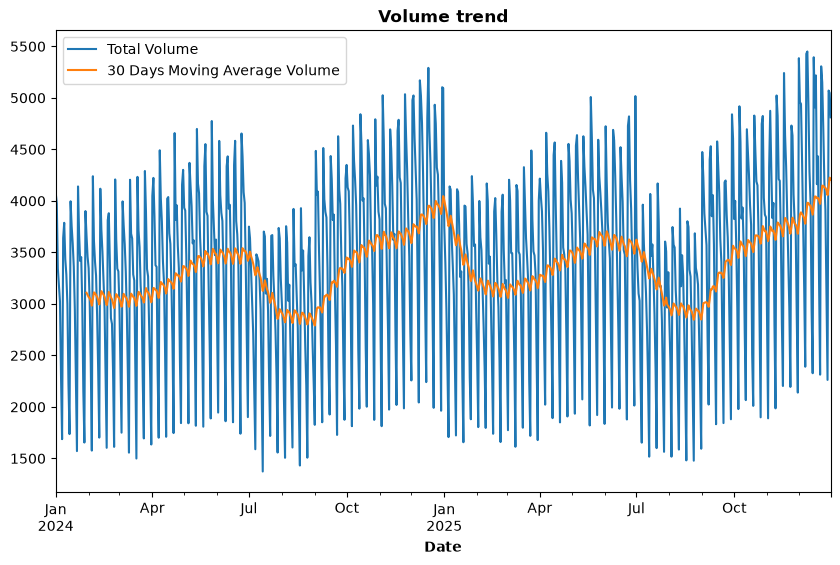

In [202]:
daily_summary_with_rolling_averages.plot(
    x='date', 
    y=['total_volume', 'volume_30_days_moving_average'], 
    kind='line', figsize=(10, 6))
plt.title("Volume trend", fontsize=12, fontweight='bold')
plt.legend(["Total Volume", "30 Days Moving Average Volume"])
plt.xlabel("Date", fontweight="bold")
plt.show()

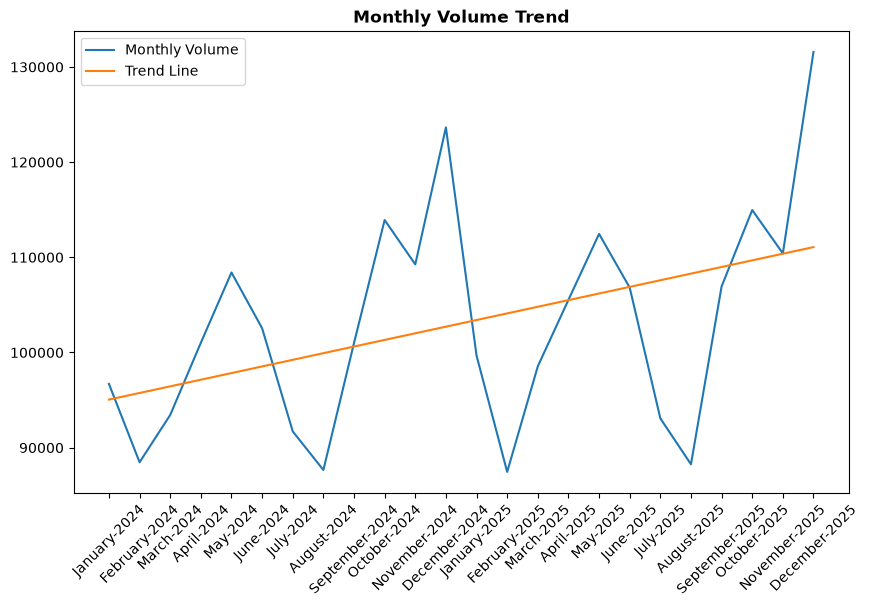

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_summary["month"].astype(str),
    monthly_summary["total_volume"]
)

plt.plot(
    monthly_summary["month"].astype(str),
    monthly_summary["trend"]
)

plt.legend([
    "Monthly Volume",
    "Trend Line"
])

plt.title("Monthly Volume Trend", fontsize=12, fontweight="bold")
plt.xticks(rotation=45)

plt.show()

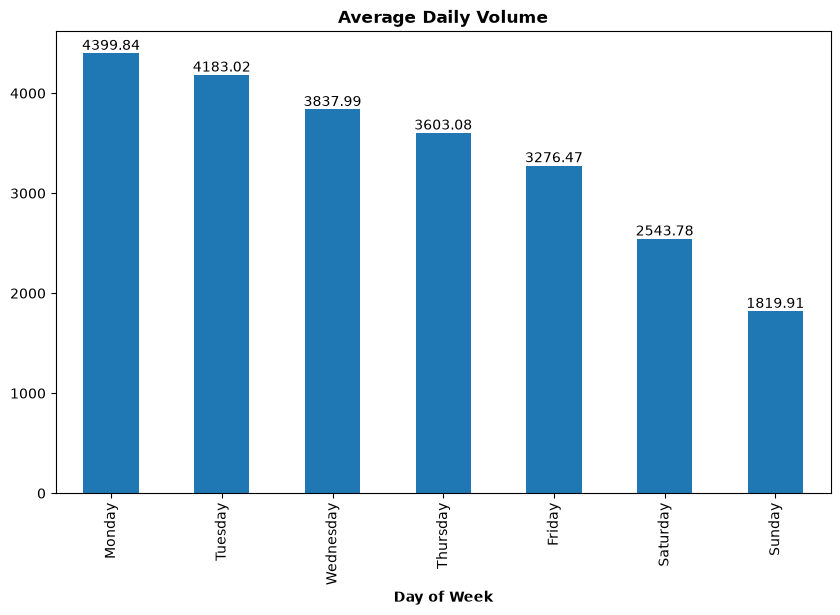

In [204]:
ax = weekly_summary.plot(x='day_of_week', y='avg_daily_volume', kind='bar', figsize=(10, 6), legend=False)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f'
    )
plt.title("Average Daily Volume", fontsize=12, fontweight="bold")
plt.xlabel("Day of Week", fontweight="bold")
plt.show()

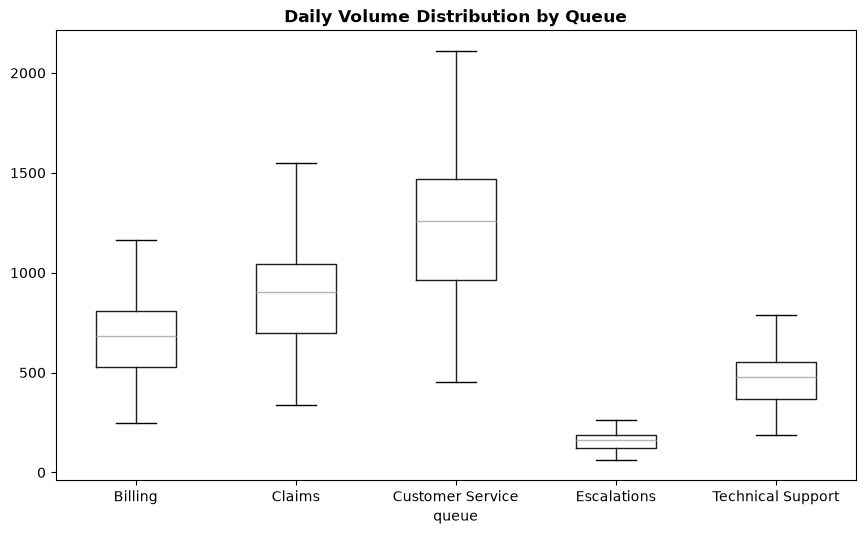

In [205]:
enriched_workload_df.boxplot(column='volume', by='queue', grid=False, figsize=(10,6))
plt.title("Daily Volume Distribution by Queue", fontsize=12, fontweight="bold")
plt.suptitle("")
plt.show()

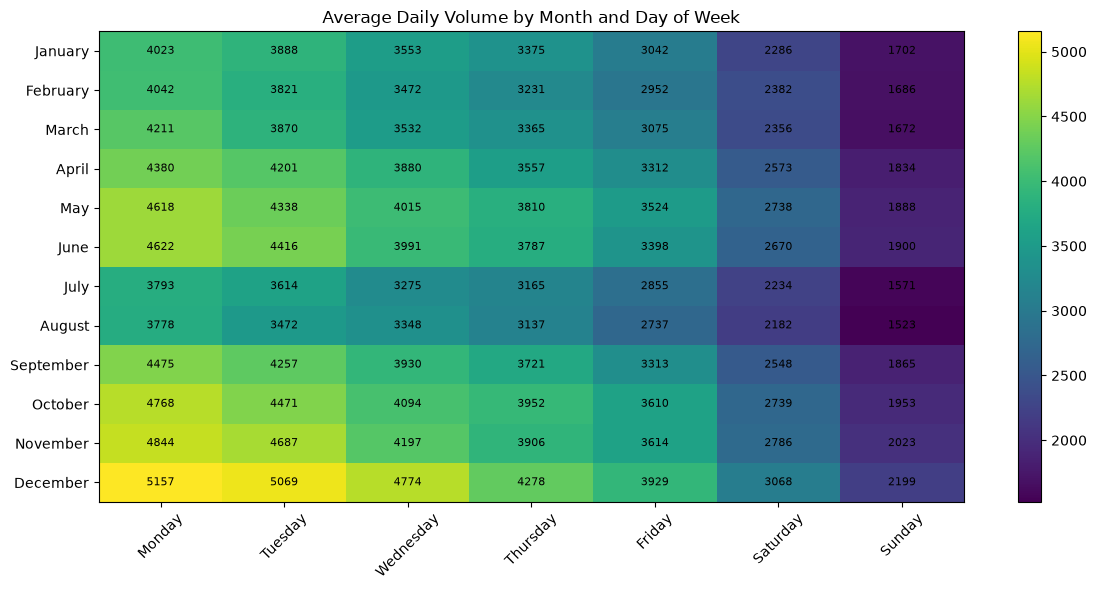

In [206]:
fig, ax = plt.subplots(figsize=(12,6))

im = ax.imshow(
    heatmap_data,
    aspect='auto'
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(
    heatmap_data.columns,
    rotation=45
)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(
    heatmap_data.index
)

plt.colorbar(im)

plt.title(
    "Average Daily Volume by Month and Day of Week"
)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        ax.text(
            j,
            i,
            f"{heatmap_data.iloc[i,j]:.0f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()

plt.show()

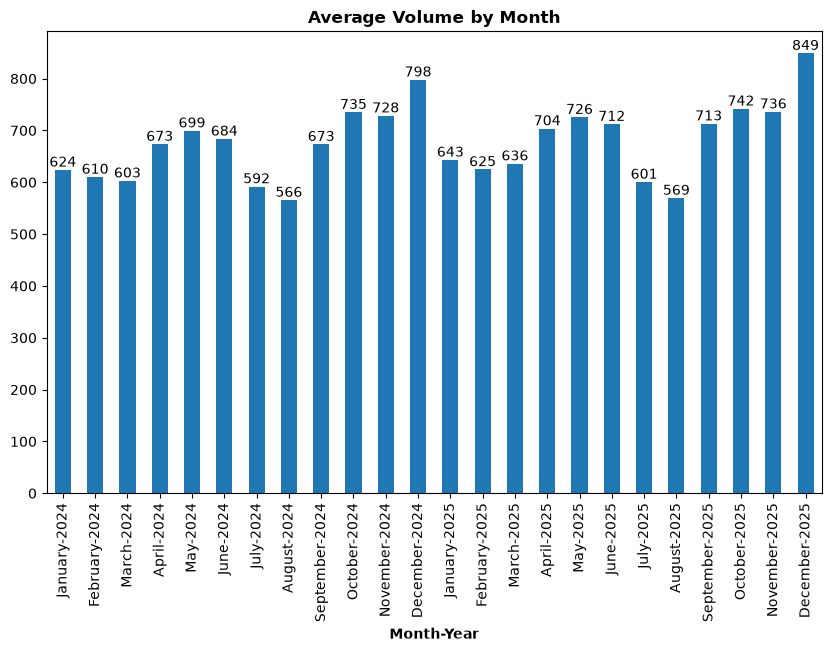

In [207]:
ax = monthly_summary.plot(
    x='month',
    y='avg_volume',
    kind='bar',
    legend=False,
    figsize=(10, 6)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f'
    )

plt.title('Average Volume by Month', fontsize=12, fontweight="bold")
plt.xlabel("Month-Year", fontweight="bold")
plt.show()

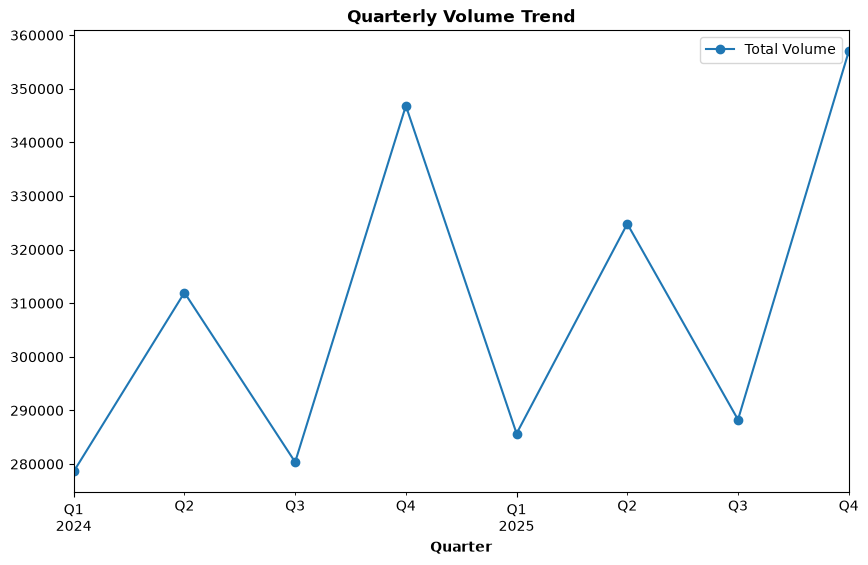

In [249]:
quarterly_summary.plot(
    x='quarter', 
    y='total_volume', 
    kind='line', 
    figsize=(10, 6),
    marker='o'
)
plt.title("Quarterly Volume Trend", fontsize=12, fontweight="bold")
plt.legend(["Total Volume"])
plt.xlabel("Quarter", fontweight="bold")
plt.show()

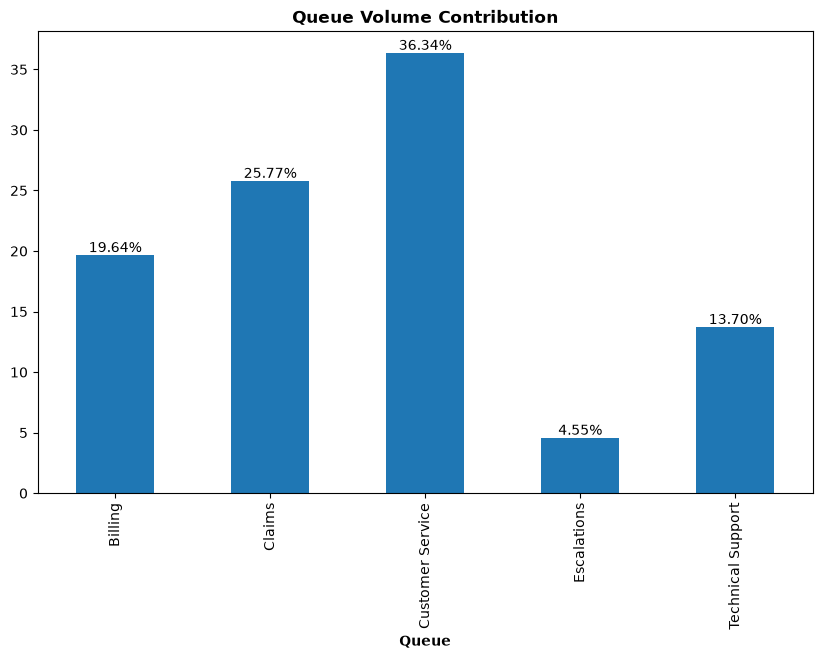

In [209]:
ax = queue_contribution.plot(x='queue', y='volume_share_pct', kind='bar', legend=False, figsize=(10, 6))
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%'
    )
plt.title("Queue Volume Contribution", fontsize=12, fontweight="bold")
plt.xlabel("Queue", fontweight="bold")
plt.show()

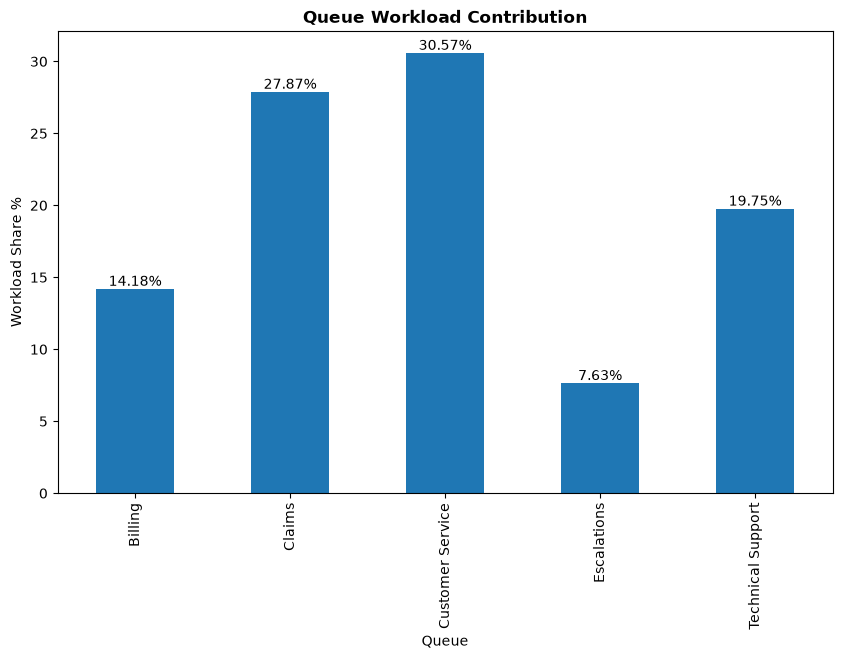

In [210]:
ax = queue_contribution.plot(
    x='queue',
    y='workload_share_pct',
    kind='bar',
    legend=False,
    figsize=(10, 6)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%'
    )

plt.ylabel('Workload Share %')
plt.xlabel('Queue')
plt.title('Queue Workload Contribution', fontsize=12, fontweight="bold")
plt.show()

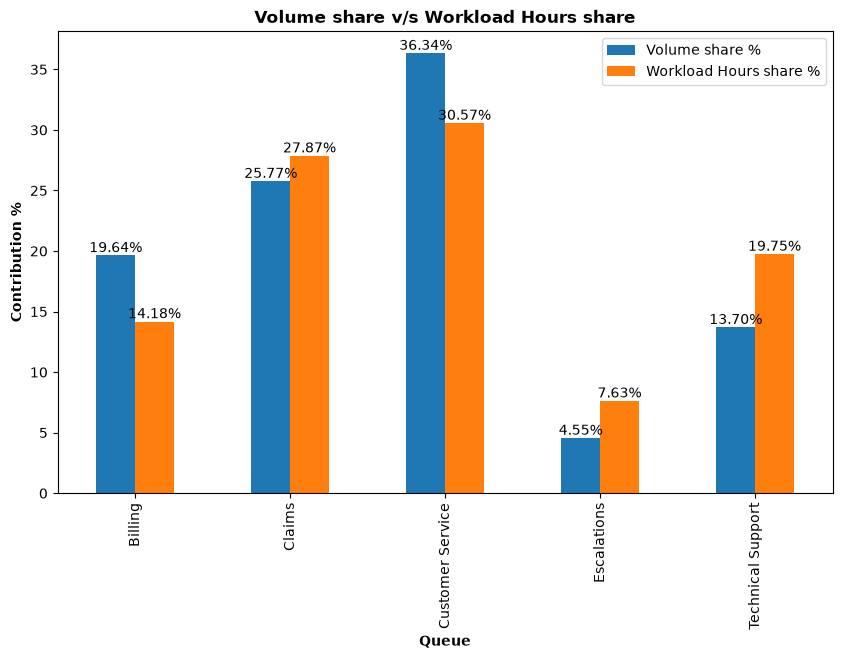

In [244]:
ax = queue_contribution.plot(
    x='queue', 
    y=['volume_share_pct', 'workload_share_pct'],
    kind='bar',
    figsize=(10, 6)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%'
    )

plt.title("Volume share v/s Workload Hours share", fontsize=12, fontweight="bold")
plt.legend(["Volume share %", "Workload Hours share %"])
plt.xlabel("Queue", fontweight="bold")
plt.ylabel("Contribution %", fontweight="bold")
plt.show()

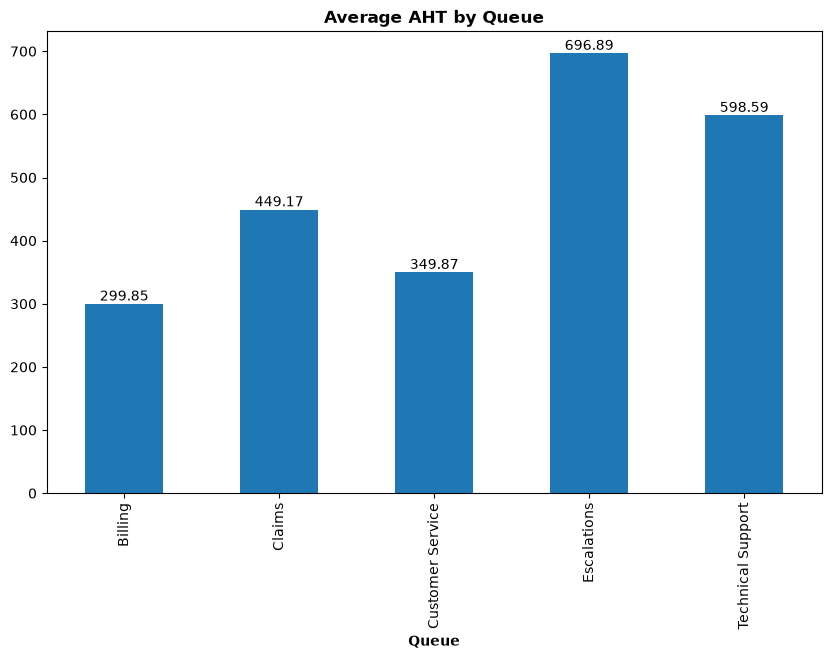

In [211]:
ax = queue_grouped.plot(x='queue', y='avg_aht', kind='bar', figsize=(10, 6), legend=False)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f'
    )
plt.title("Average AHT by Queue", fontsize=12, fontweight="bold")
plt.xlabel("Queue", fontweight="bold")
plt.show()

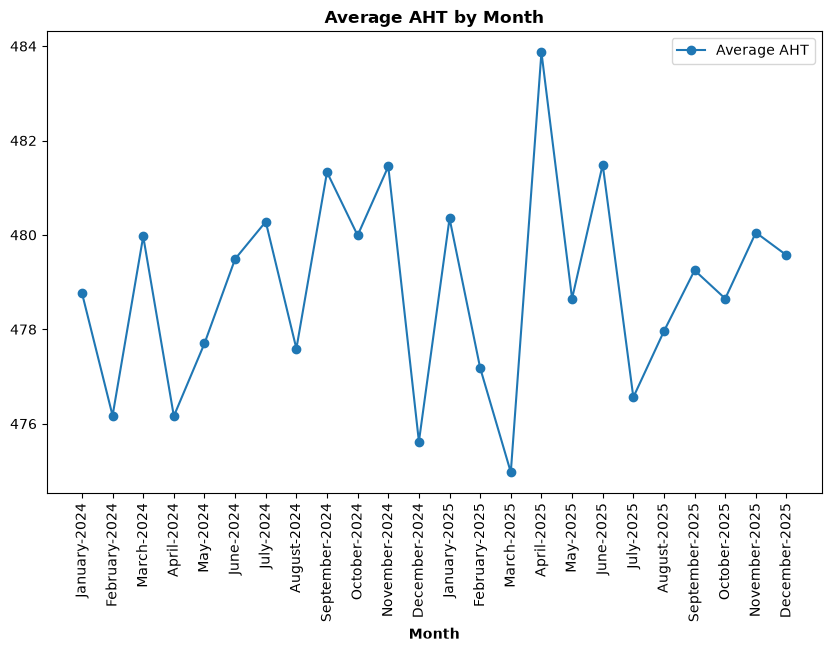

In [248]:
monthly_summary.plot(
    x='month', 
    y='avg_aht', 
    kind='line', 
    figsize=(10, 6),
    marker='o'
)
plt.title("Average AHT by Month", fontsize=12, fontweight="bold")
plt.xticks(
    ticks=range(len(monthly_summary)),
    labels=monthly_summary['month'],
    rotation=90
)
plt.xlabel("Month", fontweight="bold")
plt.legend(["Average AHT"])
plt.show()

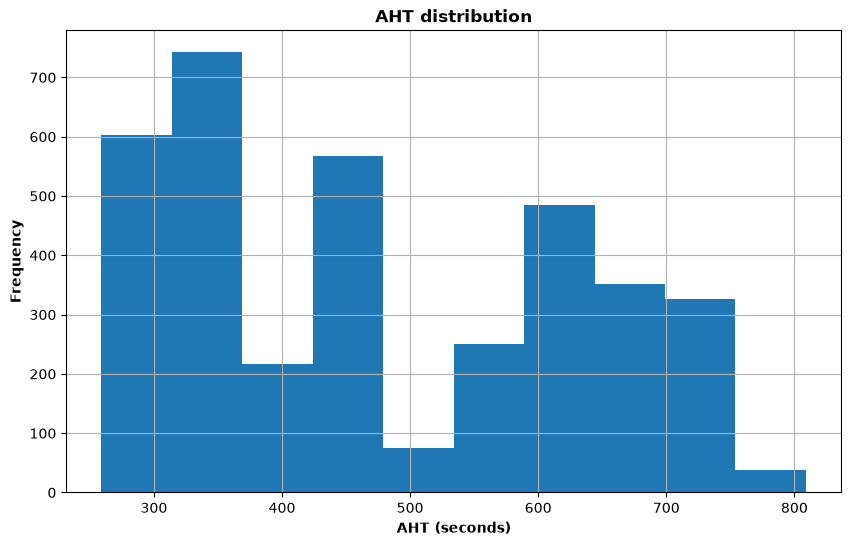

In [237]:
enriched_workload_df['aht_seconds'].hist(figsize=(10, 6))
plt.title("AHT distribution", fontsize=12, fontweight="bold")
plt.xlabel("AHT (seconds)", fontweight="bold")
plt.ylabel("Frequency", fontweight="bold")
plt.show()

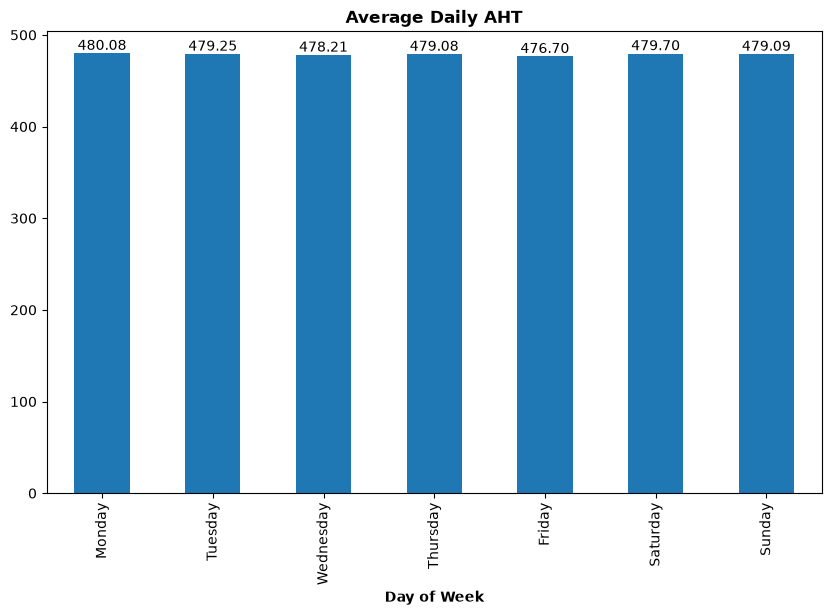

In [214]:
ax = weekly_summary.plot(x='day_of_week', y='avg_daily_aht', kind='bar', figsize=(10, 6), legend=False)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f'
    )
plt.title("Average Daily AHT", fontsize=12, fontweight="bold")
plt.xlabel("Day of Week", fontweight="bold")
plt.show()

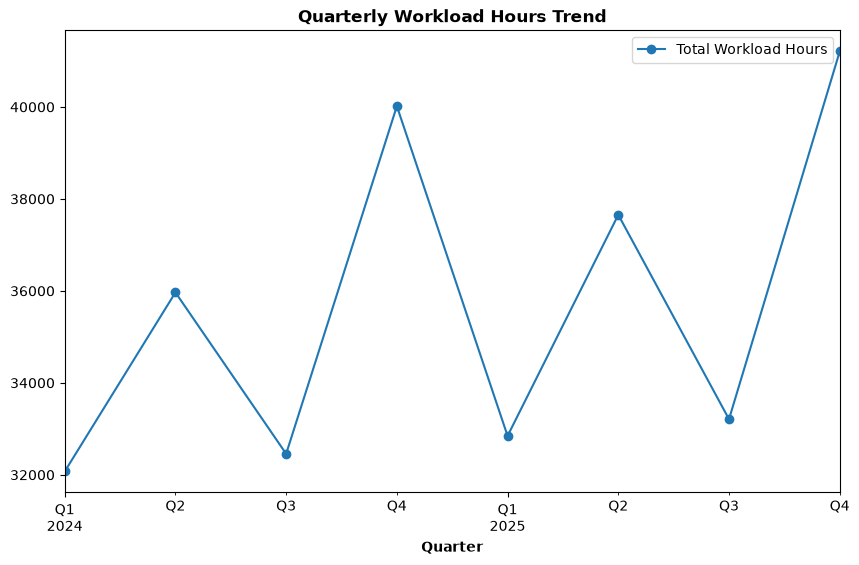

In [247]:
quarterly_summary.plot(
    x='quarter', 
    y='total_workload_hours', 
    kind='line', 
    figsize=(10, 6),
    marker='o'
)
plt.title("Quarterly Workload Hours Trend", fontsize=12, fontweight="bold")
plt.legend(["Total Workload Hours"])
plt.xlabel("Quarter", fontweight="bold")
plt.show()

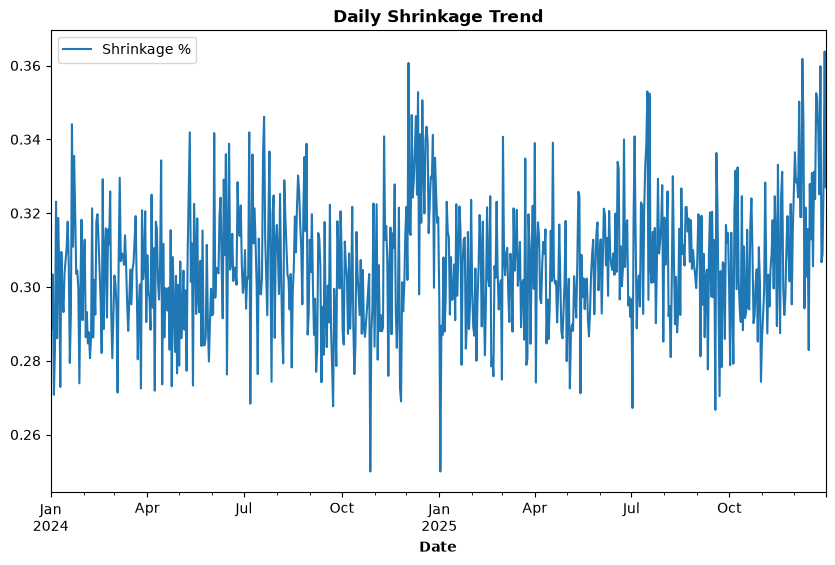

In [217]:
shrinkage_df.plot(x='date', y='shrinkage_pct', kind='line', figsize=(10, 6))
plt.title("Daily Shrinkage Trend", fontsize=12, fontweight="bold")
plt.legend(['Shrinkage %'])
plt.xlabel("Date", fontweight="bold")
plt.show()

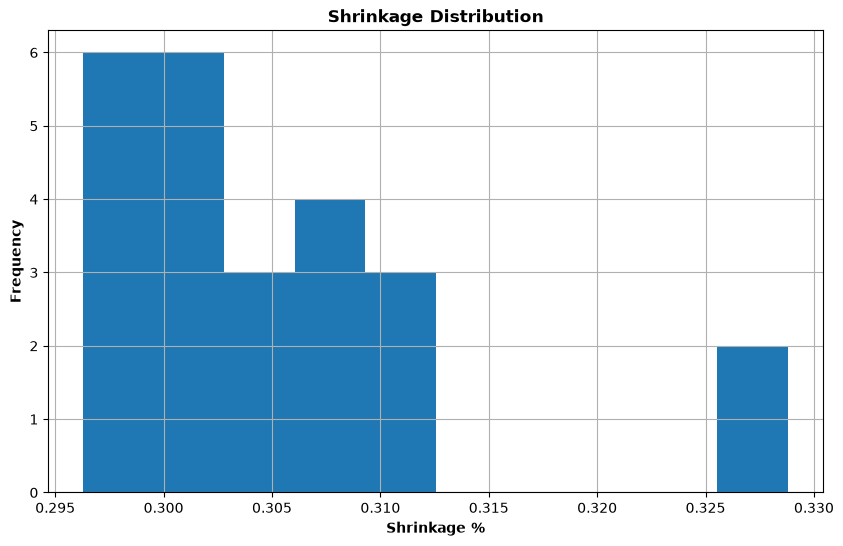

In [238]:
monthly_shrinkage_summary['shrinkage_pct'].hist(figsize=(10, 6))
plt.title("Shrinkage Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Shrinkage %", fontweight="bold")
plt.ylabel("Frequency", fontweight="bold")
plt.show()

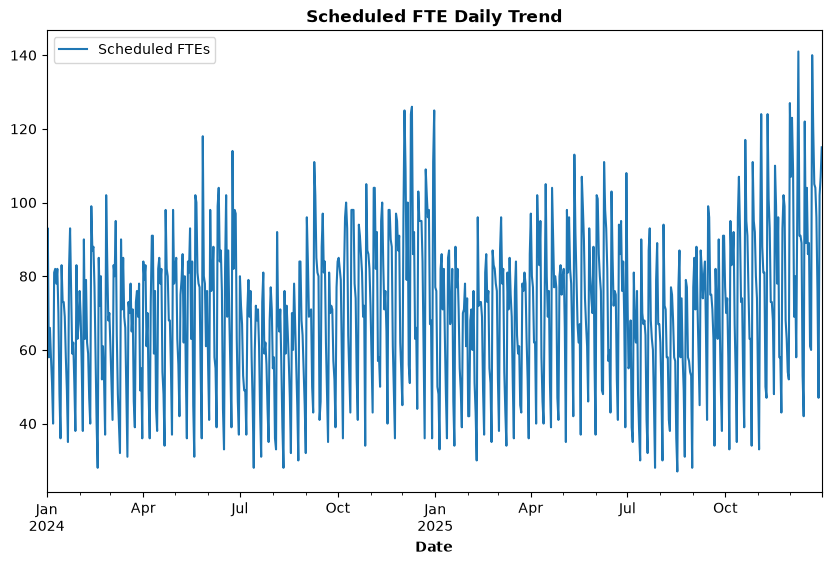

In [219]:
staffing_df.plot(x='date', y='scheduled_fte', kind='line', figsize=(10, 6))
plt.title("Scheduled FTE Daily Trend", fontsize=12, fontweight="bold")
plt.legend(['Scheduled FTEs'])
plt.xlabel("Date", fontweight="bold")
plt.show()

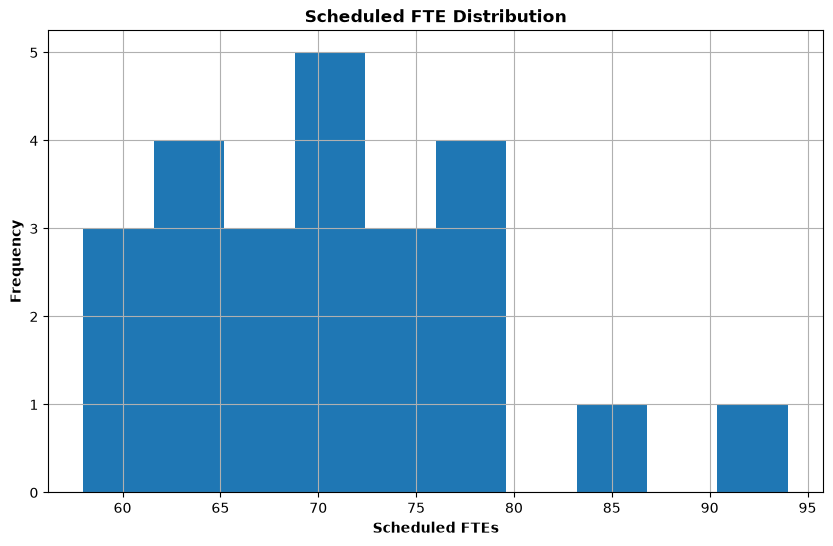

In [239]:
monthly_staffing_summary['scheduled_fte'].hist(figsize=(10, 6))
plt.title("Scheduled FTE Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Scheduled FTEs", fontweight="bold")
plt.ylabel("Frequency", fontweight="bold")
plt.show()

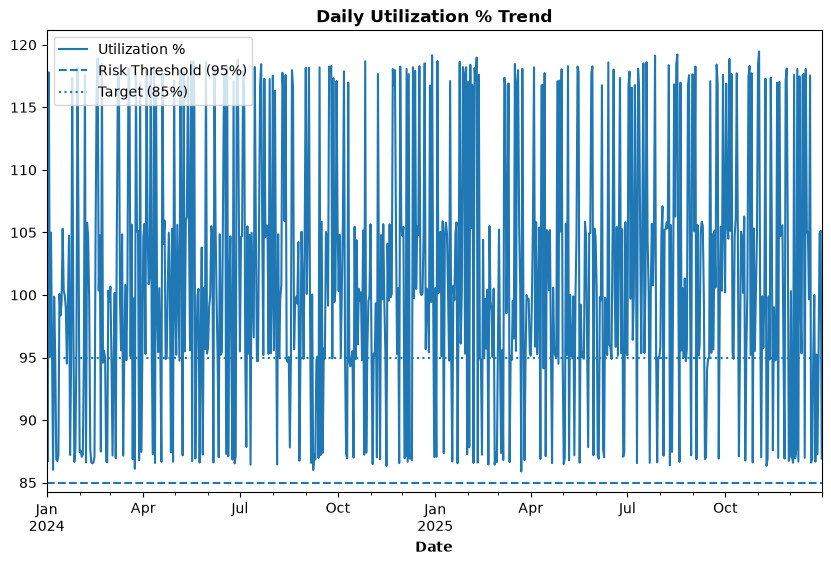

In [230]:
ax = utilization_df.plot(x='date', y='utilization_pct', kind='line', figsize=(10, 6))
ax.axhline(
    85,
    linestyle='--',
)

ax.axhline(
    95,
    linestyle=':',
)
plt.title("Daily Utilization % Trend", fontsize=12, fontweight="bold")
plt.xlabel('Date', fontweight="bold")
plt.legend(['Utilization %', 'Risk Threshold (95%)', 'Target (85%)',])
plt.show()

## Key Findings

### Workload Trends

- Total workload volume increased by 3.12% from 2024 to 2025, indicating continued business growth.
- Monthly workload trends show fluctuations throughout the year.
- Q4 consistently recorded the highest workload volumes across both years.
- December represented the peak demand period and generated the highest average monthly volumes.

### Queue Analysis

- Customer Service contributed the largest share of workload volume at 36.34%.
- Escalations contributed the smallest share of workload volume at 4.55%.
- Queue workload contribution closely followed queue volume contribution patterns.
- Customer Service and Billing collectively accounted for the majority of operational demand.

### Seasonality Analysis

- Monday exhibited the highest average daily volume across the observed period.
- Sunday consistently experienced the lowest workload volumes.
- Weekly demand patterns closely aligned with expected contact-center operating behavior.
- The Month × Day-of-Week heatmap confirmed strong weekday-driven workload seasonality.

### Average Handle Time (AHT)

- Escalations recorded the highest average handling time at 696.89 seconds.
- Despite lower transaction volumes, Escalations consumed a disproportionately higher share of operational effort due to elevated handling times.
- Average handle time remained relatively stable across different days of the week.
- No significant weekly seasonality was observed in AHT.

### Shrinkage Analysis

- Shrinkage levels remained within expected operational ranges throughout the analysis period.
- A noticeable increase in shrinkage was observed during December in both years.
- Aside from seasonal peaks, shrinkage remained relatively stable with limited month-to-month volatility.

### Staffing & Capacity

- Scheduled staffing levels broadly followed workload demand patterns.
- Utilization trends reflected the interaction between workload growth, staffing levels, and shrinkage.
- Several periods exceeded the target utilization threshold, indicating potential capacity risk.
- High-demand periods would require close workforce monitoring to maintain service levels and avoid operational strain.

### Workforce Management Implications

- Strong weekly and monthly seasonality patterns suggest that forecasting models should incorporate seasonality components.
- Queue-specific AHT differences materially impact workload requirements and staffing demand.
- December should be treated as a critical planning period due to simultaneous increases in workload and shrinkage.
- Capacity planning models should account for seasonal demand spikes and shrinkage fluctuations to ensure adequate staffing coverage.

## Exports section

In [235]:
output_dir = Path.home() / "da_projects/workforce_forecasting_and_capacity_planning_analytics/data/processed"

daily_summary.to_csv(output_dir / "daily_summary.csv", index=False)
daily_summary_with_rolling_averages.to_csv(output_dir / "daily_summary_with_rolling_averages.csv", index=False)
weekly_summary.to_csv(output_dir / "weekly_summary.csv", index=False)
monthly_summary.to_csv(output_dir / "monthly_summary.csv", index=False)
quarterly_summary.to_csv(output_dir / "quarterly_summary.csv", index=False)
queue_contribution.to_csv(output_dir / "queue_wise_contributions.csv", index=False)
utilization_df.to_csv(output_dir / "utilization_analysis.csv", index=False)
monthly_shrinkage_summary.to_csv(output_dir / "shrinkage_monthly_summary.csv", index=False)
monthly_staffing_summary.to_csv(output_dir / "staffing_monthly_summary.csv", index=False)
